In [1]:
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
k=5

In [3]:
text_file="/raid/lyu/QEBT/bt_data/en-zh/news_crawl_en_300k_hypo_5.bt"
qe_score_file="/raid/lyu/QEBT/bt_data/en-zh/news_crawl_en_300k_hypo_5.bt.QE_comet_scores"
mbr_score_file="/raid/lyu/QEBT/bt_data/en-zh/news_crawl_en_300k_hypo_5.bt.mbr.score"

In [3]:
text_file="/raid/lyu/QEBT/test_dev/test/mbr_bs/output_5/output.hypo_5"
qe_score_file="/raid/lyu/QEBT/test_dev/test/qe_bs/output_5/qe.output.score"
mbr_score_file="/raid/lyu/QEBT/test_dev/test/mbr_bs/output_5/mbr.score"
model_score="/raid/lyu/QEBT/test_dev/test/mbr_bs/output_5/ct2_output.hypo_5.score"

In [2]:
#高資源
text_file="/raid/lyu/QEBT/test_dev/test_high_base/mbr_bs/output_5/ct2_output.hypo_5"
qe_score_file="/raid/lyu/QEBT/test_dev/test_high_base/qe_bs/output_5/qe.output.score"
mbr_score_file="/raid/lyu/QEBT/test_dev/test_high_base/mbr_bs/output_5/mbr.score"
model_score="/raid/lyu/QEBT/test_dev/test_high_base/mbr_bs/output_5/ct2_output.hypo_5.score"

In [3]:
with open(text_file, "r", encoding="utf-8") as fin:
    print("start to load text")
    lines=fin.readlines()
    texts=[line.strip() for line in lines]
    print("successfully load text")

start to load text
successfully load text


In [4]:
with open(qe_score_file, "r", encoding="utf-8") as fin:
    print("start to load scores")
    lines=fin.readlines()
    qe_scores=[float(line.strip()) for line in lines]
    print("successfully load qe scores")
with open(mbr_score_file, "r", encoding="utf-8") as fin:
    print("start to load scores")
    lines=fin.readlines()
    mbr_scores=[json.loads(line.strip()) for line in lines]
    print("successfully load mbr scores")
with open(model_score, "r", encoding="utf-8") as fin:
    print("start to load scores")
    lines=fin.readlines()
    model_scores=[float(line.strip()) for line in lines]
    print("successfully load model scores")
tmp=[]
for i in range(len(mbr_scores)):
    tmp.extend(mbr_scores[i])
mbr_scores=tmp
assert len(texts)==len(qe_scores)
assert len(texts)==len(mbr_scores)
assert len(texts)==len(model_scores)

start to load scores
successfully load qe scores
start to load scores
successfully load mbr scores
start to load scores
successfully load model scores


extract: 100%|██████████| 8792/8792 [00:00<00:00, 497414.49it/s]


analysis:
2 0.20905368516833486
1 0.20211555959963604
3 0.20097816196542312
4 0.19449499545040946
5 0.19335759781619655


(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   3.,   0.,   1.,   1.,   2.,   2.,
          1.,   3.,   1.,   0.,   1.,   3.,   0.,   1.,   2.,   2.,   4.,
          3.,   5.,   4.,   2.,   3.,   2.,   5.,   5.,   4.,  11.,   4.,
          4.,  12.,  10.,   7.,  12.,   9.,   5.,   5.,   9.,   6.,   7.,
         10.,  11.,  11.,  14.,   9.,  18.,  27.,  18.,  17.,  22.,  17.,
         18.,  29.,  20.,  33.,  31.,  31.,  38.,  41.,  42.,  55.,  67.,
         72.,  82.,  90., 109., 117., 145., 146., 177., 212., 287., 305.,
        370., 474., 559., 704., 759., 870., 881., 756., 522., 317.,  86.,
         10.]),
 array([0.35351589, 0.35897371, 0.36443153, 0.36988935, 0.37534717,
        0.38080499, 0.38626281, 0.39172063, 0.39717845, 0.40263627,
        0.40809409, 0.41355191, 0.41900973, 0.42446755, 0.42992536,
        0.43538318, 0.440841  , 0.44629882, 0.45175664, 0.45721446,
        0.46267228, 0.4681301 , 0.47358792, 0.

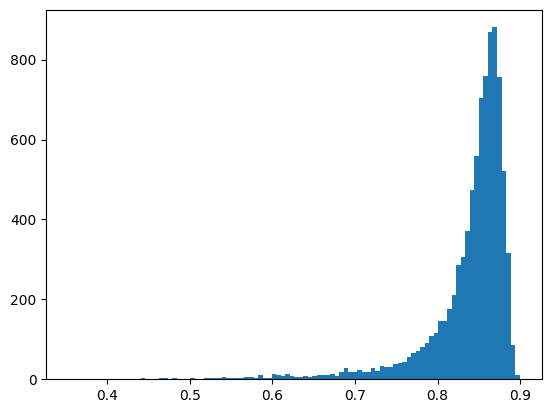

In [5]:
#QE
qe_results=[]
qe_analysis={}
for i in tqdm(range(len(qe_scores)//k),desc="extract",total=len(qe_scores)//k):
    cand_scores=qe_scores[i*k:(i+1)*k]
    max_score=max(cand_scores)
    max_index=cand_scores.index(max_score)+1
    qe_results.append(max_score)
    if max_index not in qe_analysis:
        qe_analysis[max_index]=1
    else:
        qe_analysis[max_index]+=1
#sort
qe_analysis=dict(sorted(qe_analysis.items(),key=lambda item:item[1],reverse=True))
print("analysis:")
for key in qe_analysis:
    print(key,qe_analysis[key]/(len(qe_scores)//k))
plt.hist(qe_results,bins=100)

extract: 100%|██████████| 8792/8792 [00:00<00:00, 500431.83it/s]

analysis:
1 0.35247952684258416
2 0.2302092811646952
3 0.1868744313011829
4 0.14024112829845314
5 0.09019563239308462


(array([  1.,   1.,   1.,   0.,   0.,   0.,   2.,   0.,   0.,   1.,   1.,
          0.,   0.,   2.,   4.,   1.,   1.,   3.,   2.,   4.,   1.,   3.,
          3.,   2.,   4.,   1.,   2.,   1.,   3.,   6.,   6.,  10.,   9.,
          3.,   4.,   9.,   8.,  10.,   8.,  13.,  14.,  18.,  19.,  18.,
         11.,  21.,  23.,  21.,  23.,  19.,  28.,  30.,  35.,  30.,  37.,
         48.,  43.,  50.,  56.,  51.,  61.,  74.,  72.,  92.,  85.,  93.,
        118., 114., 116., 133., 124., 130., 138., 132., 168., 202., 237.,
        223., 255., 281., 259., 308., 308., 331., 347., 389., 383., 359.,
        394., 389., 371., 388., 287., 244., 194., 124.,  96.,  29.,  15.,
          4.]),
 array([0.62141663, 0.62504436, 0.62867209, 0.63229982, 0.63592755,
        0.63955528, 0.64318302, 0.64681075, 0.65043848, 0.65406621,
        0.65769394, 0.66132167, 0.6649494 , 0.66857713, 0.67220487,
        0.6758326 , 0.67946033, 0.68308806, 0.68671579, 0.69034352,
        0.69397125, 0.69759898, 0.70122671, 0.

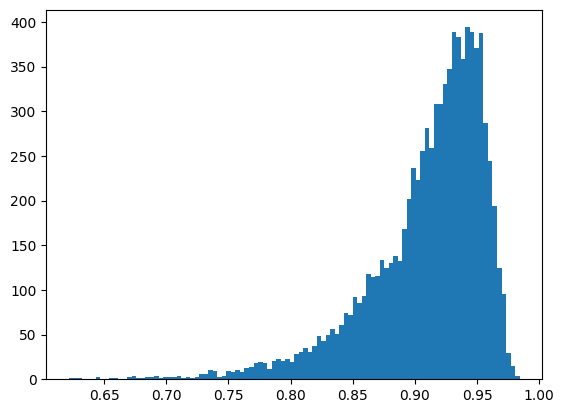

In [7]:
#MBR
mbr_results=[]
mbr_analysis={}
for i in tqdm(range(len(mbr_scores)//k),desc="extract",total=len(mbr_scores)//k):
    cand_scores=mbr_scores[i*k:(i+1)*k]
    max_score=max(cand_scores)
    max_index=cand_scores.index(max_score)+1
    mbr_results.append(max_score)
    if max_index not in mbr_analysis:
        mbr_analysis[max_index]=1
    else:
        mbr_analysis[max_index]+=1
#sort
mbr_analysis=dict(sorted(mbr_analysis.items(),key=lambda item:item[1],reverse=True))
print("analysis:")
for key in mbr_analysis:
    print(key,mbr_analysis[key]/(len(mbr_scores)//k))
plt.hist(mbr_results,bins=100)

In [8]:
#統計量、相関係数
from scipy import stats
import numpy as np
assert len(mbr_scores)==len(qe_scores)
print(f'QE mean: {np.mean(qe_scores)}, std: {np.std(qe_scores)}, max: {np.max(qe_scores)}, min: {np.min(qe_scores)}, median: {np.median(qe_scores)}')
print(f'MBR mean: {np.mean(mbr_scores)}, std: {np.std(mbr_scores)}, max: {np.max(mbr_scores)}, min: {np.min(mbr_scores)}, median: {np.median(mbr_scores)}')
#QE MBR間の相関係数、及びモデルのスコアとの相関係数
print(f'QE MBR correlation: {stats.pearsonr(qe_scores,mbr_scores)[0]}')


print(f'QE model score correlation: {stats.pearsonr(qe_scores,model_scores)[0]}')
print(f'MBR model score correlation: {stats.pearsonr(mbr_scores,model_scores)[0]}')


QE mean: 0.7400545226086314, std: 0.12453235322283486, max: 0.8986058235168457, min: 0.21087270975112915, median: 0.7772891223430634
MBR mean: 0.8984780431898808, std: 0.05806545291760205, max: 0.9841897487640381, min: 0.3933175802230835, median: 0.9139646589756012
QE MBR correlation: 0.7673100385580885
QE model score correlation: 0.6129110572166023
MBR model score correlation: 0.5522192740231928


In [9]:
#ランク相関係数
from scipy.stats import spearmanr
from scipy.stats import rankdata
qe_rank=[]
mbr_rank=[]
original_rank=[]
for i in tqdm(range(len(mbr_scores)//k),desc="extract",total=len(mbr_scores)//k):
    tmp=rankdata(model_scores[i*k:(i+1)*k], method='dense').astype(int).tolist()
    tmp=[k-x+1 for x in tmp]
    original_rank.extend(tmp)
    tmp=rankdata(qe_scores[i*k:(i+1)*k], method='dense').astype(int).tolist()
    tmp=[k-x+1 for x in tmp]
    qe_rank.extend(tmp)
    tmp=rankdata(mbr_scores[i*k:(i+1)*k], method='dense').astype(int).tolist()
    tmp=[k-x+1 for x in tmp]
    mbr_rank.extend(tmp)
assert len(qe_rank)==len(mbr_rank)==len(original_rank)
print(f'QE - MBR rank correlation: {spearmanr(qe_rank,mbr_rank)[0]}')
print(f'QE - beam search correlation: {spearmanr(qe_rank,original_rank)[0]}')
print(f'MBR - beam search correlation: {spearmanr(mbr_rank,original_rank)[0]}')



extract: 100%|██████████| 8792/8792 [00:02<00:00, 4353.09it/s]

QE - MBR rank correlation: 0.32947717681306415
QE - beam search correlation: 0.0952940423979376
MBR - beam search correlation: 0.2388975678790757


In [9]:
src_file="/raid/lyu/QEBT/news_crawl_zh/news.2022.zh.shuffled.deduped.300000"
with open(src_file, "r", encoding="utf-8") as fin:
    print("start to load text")
    lines=fin.readlines()
    src_texts=[line.strip() for line in lines]
    print("successfully load text")
index_negatives=[]
for i in tqdm(range(len(qe_scores)),desc="extract",total=len(qe_scores)):
    if qe_scores[i]<0:
        index_negatives.append(i)
print(len(index_negatives))

start to load text
successfully load text


extract: 100%|██████████| 1499970/1499970 [00:00<00:00, 2385865.83it/s]

0


In [6]:

#bin分けて、binごとにランク分布や相関係数を計算
#bin: 0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
qe_bin_dir={0.0:{},0.1:{},0.2:{},0.3:{},0.4:{},0.5:{},0.6:{},0.7:{},0.8:{},0.9:{}}
mbr_bin_dir={0.0:{},0.1:{},0.2:{},0.3:{},0.4:{},0.5:{},0.6:{},0.7:{},0.8:{},0.9:{}}
for i in tqdm(range(len(qe_scores)//k),desc="extract",total=len(qe_scores)//k):
    cand_scores=qe_scores[i*k:(i+1)*k]
    max_score=max(cand_scores)
    max_index=cand_scores.index(max_score)+1
    bin_index=str(max_score)[:3]
    bin_index=float(bin_index)
    assert bin_index in qe_bin_dir,f'bin_index: {bin_index}'
    if max_index not in qe_bin_dir[bin_index]:
        qe_bin_dir[bin_index][max_index]=1
    else:
        qe_bin_dir[bin_index][max_index]+=1
    cand_scores=mbr_scores[i*k:(i+1)*k]
    max_score=max(cand_scores)
    max_index=cand_scores.index(max_score)+1
    bin_index=str(max_score)[:3]
    bin_index=float(bin_index)
    assert bin_index in mbr_bin_dir,f'bin_index: {bin_index}'
    if max_index not in mbr_bin_dir[bin_index]:
        mbr_bin_dir[bin_index][max_index]=1
    else:
        mbr_bin_dir[bin_index][max_index]+=1
#binごとに、QE/MBRのスコアの一番高いhypotheseはbeam searchの何番目にあるかを計算

print("qe bin:")
for key in qe_bin_dir:
    tmp={}
    total=sum(qe_bin_dir[key].values())
    for key2 in qe_bin_dir[key]:
        tmp[key2]=qe_bin_dir[key][key2]/total
    tmp=dict(sorted(tmp.items(),key=lambda item:item[1],reverse=True))
    print(key,tmp)
print("mbr bin:")
for key in mbr_bin_dir:
    tmp={}
    total=sum(mbr_bin_dir[key].values())
    for key2 in mbr_bin_dir[key]:
        tmp[key2]=mbr_bin_dir[key][key2]/total
    tmp=dict(sorted(tmp.items(),key=lambda item:item[1],reverse=True))
    print(key,tmp)

extract: 100%|██████████| 8792/8792 [00:00<00:00, 170383.73it/s]

qe bin:
0.0 {}
0.1 {}
0.2 {}
0.3 {2: 1.0}
0.4 {3: 0.3125, 1: 0.25, 4: 0.25, 2: 0.125, 5: 0.0625}
0.5 {5: 0.296875, 3: 0.21875, 1: 0.1875, 4: 0.1875, 2: 0.109375}
0.6 {4: 0.22815533980582525, 1: 0.2087378640776699, 3: 0.19902912621359223, 2: 0.18446601941747573, 5: 0.1796116504854369}
0.7 {1: 0.2139689578713969, 2: 0.21286031042128603, 3: 0.1973392461197339, 5: 0.18957871396895787, 4: 0.18625277161862527}
0.8 {2: 0.21018019202946206, 3: 0.20110482704195712, 1: 0.20057871892673945, 4: 0.19452847560173617, 5: 0.19360778640010523}
0.9 {}
mbr bin:
0.0 {}
0.1 {}
0.2 {}
0.3 {}
0.4 {}
0.5 {}
0.6 {1: 1.0}
0.7 {1: 0.3333333333333333, 2: 0.2, 4: 0.16666666666666666, 3: 0.16666666666666666, 5: 0.13333333333333333}
0.8 {1: 0.31457431457431456, 2: 0.22943722943722944, 3: 0.1976911976911977, 4: 0.13131313131313133, 5: 0.12698412698412698}
0.9 {1: 0.41831928606841845, 2: 0.22446703024293505, 3: 0.16732771442736738, 4: 0.118368864650471, 5: 0.07151710461080812}
